In [3]:
import ikpy.chain
import numpy as np
import ikpy.utils.plot as plot_utils

In [4]:
my_chain = ikpy.chain.Chain.from_urdf_file("arctos.urdf")

e:\Anaconda\Lib\site-packages\ikpy\urdf\URDF.py:261: UserWarning: Joint Gripper_joint is of type: fixed, but has an 'axis' attribute defined. This is not in the URDF spec and thus this axis is ignored
  warnings.warn("Joint {} is of type: fixed, but has an 'axis' attribute defined. This is not in the URDF spec and thus this axis is ignored".format(joint.attrib["name"]))
e:\Anaconda\Lib\site-packages\ikpy\chain.py:60: UserWarning: Link Base link (index: 0) is of type 'fixed' but set as active in the active_links_mask. In practice, this fixed link doesn't provide any transformation so is as it were inactive
  warnings.warn("Link {} (index: {}) is of type 'fixed' but set as active in the active_links_mask. In practice, this fixed link doesn't provide any transformation so is as it were inactive".format(link.name, link_index))
e:\Anaconda\Lib\site-packages\ikpy\chain.py:60: UserWarning: Link Gripper_joint (index: 7) is of type 'fixed' but set as active in the active_links_mask. In practice

In [5]:
for joint in my_chain.links:
    if hasattr(joint, 'bounds') and joint.bounds is not None:
        print(f"{joint.name}: lower={joint.bounds[0]}, upper={joint.bounds[1]}")

Base link: lower=-inf, upper=inf
X_joint: lower=-3.141592653589793, upper=3.141592653589793
Y_joint: lower=-0.96, upper=2.18
Z_joint: lower=-1.5707963267948966, upper=1.2217304763960306
A_joint: lower=-3.141592653589793, upper=3.141592653589793
B_joint: lower=-1.55, upper=1.55
C_joint: lower=-3.141592653589793, upper=3.141592653589793
Gripper_joint: lower=-1e-07, upper=1e-07
Left_jaw_joint: lower=0.0, upper=0.015


In [6]:
target_position = [-0.53031     ,  0   , 0.2]
print("The angles of each joints are : ", my_chain.inverse_kinematics(target_position))

The angles of each joints are :  [ 0.         -1.57803986  1.29663189 -0.68854203  1.48301444  0.19163356
  2.00792567  0.          0.00561036]


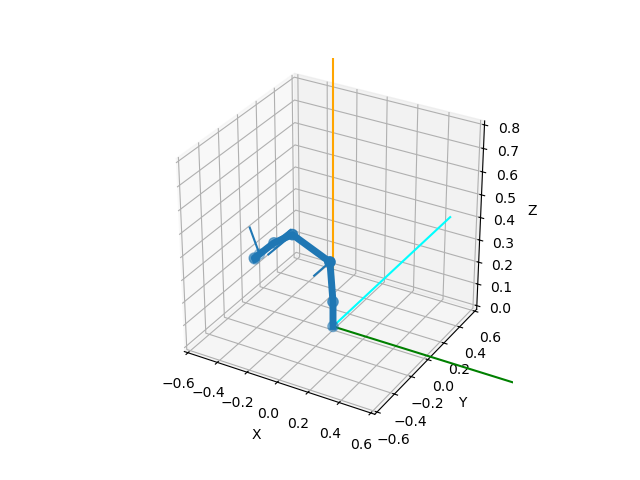

In [7]:
import numpy as np
%matplotlib widget
import matplotlib.pyplot as plt
fig, ax = plot_utils.init_3d_figure()
ax.set_zlim(0, 0.8)
ax.set_xlim(-0.6, 0.6)
ax.set_ylim(-0.6, 0.6)
ax.set_box_aspect([1, 1, 1])
my_chain.plot(my_chain.inverse_kinematics(target_position), ax)

In [8]:
real_frame = my_chain.forward_kinematics([0, 0, 0, 0, 0, 0, 0 ,0, 0])
print("Computed position vector : %s" % (real_frame[:3, 3]))
real_frame

Computed position vector : [ 0.        -0.323031   0.5685601]


array([[ 1.       ,  0.       ,  0.       ,  0.       ],
       [ 0.       ,  1.       ,  0.       , -0.323031 ],
       [ 0.       ,  0.       ,  1.       ,  0.5685601],
       [ 0.       ,  0.       ,  0.       ,  1.       ]])